In [1]:
import pandas as pd
import numpy as np
import sys
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index
import matplotlib.pyplot as plt
from lifelines.statistics import logrank_test
from typing import Dict, Optional, Tuple, Any, List
import math

sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
from SynOmics.processing.metadata import MetaData
dataset_dict = {}
original_data = pd.read_csv("Data/original_data.csv", index_col = 0)
dataset_dict["Origin"] = original_data
seed = 42
syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
synthetic_data_dictionary = {}
for i, tool in enumerate(syn_datas):
    syn_df = pd.read_csv(f"Data/{syn_datas[i]}.csv", index_col = 0)
    dataset_dict[tool] = syn_df
original_data.head()

,Cohort,Arm,Sex,Age,MSKCC,Sarc,Rhab,Number_of_Prior_Therapies,Tumor_Sample_Primary_or_Metastasis,Tumor_Shrinkage,...,ENSG00000198899.2,ENSG00000198938.2,ENSG00000198840.2,ENSG00000212907.2,ENSG00000198886.2,ENSG00000210176.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2
Patient_ID,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,62.0,FAVORABLE,No,No,2.0,PRIMARY,-16.406250,...,32.02459,32.43928,28.87370,29.40491,34.00210,21.13002,31.87140,31.90028,21.26386,28.67162
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,67.0,FAVORABLE,No,No,2.0,PRIMARY,-40.000000,...,34.67436,34.35974,33.35211,34.23558,34.75711,21.13002,33.69635,33.57917,21.26386,33.96374
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,62.0,POOR,No,No,1.0,PRIMARY,-89.436620,...,33.92360,33.17470,32.86634,32.95676,34.37301,21.13002,33.46758,32.99777,21.26386,33.29667
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,60.0,FAVORABLE,No,No,3.0,PRIMARY,11.787072,...,33.25229,32.88098,33.23512,34.18982,34.09013,21.13002,33.52007,33.08947,21.26386,32.90812
G138701_RCCBMS-00163-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,76.0,INTERMEDIATE,No,No,2.0,PRIMARY,0.000000,...,27.94141,29.16648,28.87370,29.40491,32.73904,21.13002,30.58496,28.49402,21.26386,28.67162


In [11]:
dataset_dict['gaussiancopula_42'].loc[:,'ENSG00000230753.6'].describe()

count      311.000000
mean      -145.878765
std       2960.839423
min     -52191.532514
25%         20.978430
50%         20.978430
75%         20.978430
max        402.308042
Name: ENSG00000230753.6, dtype: float64

In [12]:
dataset_dict['Origin'].loc[:,'ENSG00000230753.6'].describe()

count    311.000000
mean      21.121762
std        0.707716
min       20.954430
25%       20.972530
50%       20.978430
75%       20.978430
max       27.320010
Name: ENSG00000230753.6, dtype: float64

In [2]:
# -*- coding: utf-8 -*-
"""
Plot Kaplan–Meier curves comparing two phenotype values (e.g. mutation vs wildtype)
for each dataset and return a summary table with p-value, C-index and HR for each dataset.

The function accepts a `phenotype` mapping where the key is the column name and the
value is a list (length == 2) with the two values to compare, e.g. {"PBRM1": ["MUT", "WT"]}.
Using an explicit mapping avoids assumptions about allowed labels in the data.

Args:
    datasets_dict (dict): Mapping dataset name to pandas.DataFrame. Each DataFrame
        should contain the columns specified by `time_target`, `event_target` and
        the phenotype column.
    phenotype (dict): A mapping {column_name: [value_A, value_B]} specifying which
        column to use and which two values to compare (order defines A vs B).
    treatment (Optional[str]): If provided and the DataFrames contain an "Arm" column,
        only rows with Arm == treatment will be used. If None, no filtering by Arm.
    time_target (str): Column name with duration/time (numeric).
    event_target (str): Column name with event indicator (1/0 or bool).
    ncols (int): Number of columns for the grid layout. Rows are computed to fit
        all datasets.
    figsize (Optional[Tuple[float, float]]): Matplotlib figure size (width, height).
        If None the figure size is computed automatically from ncols and nrows.
    show_censors (bool): Whether to draw censor markers on KM curves.
    ci_show (bool): Whether to draw confidence intervals for KM curves.
    title_prefix (Optional[str]): Prefix for each subplot title.

Returns:
    tuple: (matplotlib.figure.Figure, pandas.DataFrame)
        - Figure: The created matplotlib Figure with axes arranged (nrows, ncols).
        - DataFrame: Summary table where rows are dataset names and columns are:
            ['Datasets', 'pvalue', 'C-index', 'HR'].

Raises:
    ValueError: If datasets_dict is empty, ncols < 1, or phenotype is not a single mapping
        with exactly two comparison values.
"""


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index


def plot_survival_grid(
    datasets_dict: Dict[str, pd.DataFrame],
    phenotype: Dict[str, List[Any]],
    treatment: Optional[str] = None,
    time_target: str = "OS",
    event_target: str = "OS_CNSR",
    ncols: int = 1,
    figsize: Optional[Tuple[float, float]] = None,
    show_censors: bool = True,
    ci_show: bool = False,
    title_prefix: Optional[str] = "Survival",
) -> Tuple[plt.Figure, pd.DataFrame]:
    """
    See module docstring above for detailed parameter descriptions.
    """
    if not datasets_dict:
        raise ValueError("datasets_dict must not be empty.")
    if ncols < 1:
        raise ValueError("ncols must be >= 1.")
    if not isinstance(phenotype, dict) or len(phenotype) == 0:
        raise ValueError("phenotype must be a dict with one mapping {column_name: [valA, valB]}.")
    if len(phenotype) > 1:
        # For now we only support a single phenotype comparison (one column -> two values).
        raise ValueError("phenotype must contain exactly one key (one column) to compare.")

    # extract column and the two comparison values
    ph_column, ph_values = next(iter(phenotype.items()))
    if not isinstance(ph_values, (list, tuple)) or len(ph_values) != 2:
        raise ValueError("phenotype value must be a list/tuple of exactly two values: [value_A, value_B].")

    val_A, val_B = ph_values  # A vs B comparison

    dataset_names = list(datasets_dict.keys())
    n_datasets = len(dataset_names)

    nrows = math.ceil(n_datasets / ncols)

    # automatic figsize if not provided: width per column ~4.0, height per row ~3.5
    if figsize is None:
        width_per_col = 4.0
        height_per_row = 3.5
        fig_w = width_per_col * ncols
        fig_h = height_per_row * nrows
        figsize = (fig_w, fig_h)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()

    summary_rows = []

    # colors for groups
    color_A = "#e40c69"  # e.g., MUT-like
    color_B = "#2e3092"  # e.g., WT-like

    for idx, ds_name in enumerate(dataset_names):
        ax = axes_flat[idx]
        df_raw = datasets_dict[ds_name].copy()

        # Filter by treatment if requested
        if treatment is not None and "Arm" in df_raw.columns:
            df = df_raw[df_raw["Arm"] == treatment].copy()
        else:
            df = df_raw.copy()

        # Ensure event/time columns present and coerced
        if event_target in df.columns:
            try:
                df[event_target] = df[event_target].astype(int).fillna(0)
            except Exception:
                df[event_target] = pd.to_numeric(df[event_target], errors="coerce").fillna(0).astype(int)
        else:
            df[event_target] = 0

        if time_target in df.columns:
            df[time_target] = pd.to_numeric(df[time_target], errors="coerce")
        else:
            df[time_target] = np.nan

        # Subset by phenotype values using exact equality
        df_A = df[df[ph_column] == val_A]
        df_B = df[df[ph_column] == val_B]

        n_A = len(df_A)
        n_B = len(df_B)

        # If both groups empty, annotate and continue
        if n_A == 0 and n_B == 0:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            pvalue = np.nan
            cindex_text = "NA"
            hr_text = "NA"
        else:
            # Fit and plot KM curves
            kmf = KaplanMeierFitter()
            if n_B > 0 and df_B[time_target].notna().any():
                try:
                    kmf.fit(df_B[time_target], event_observed=df_B[event_target], label=f"{val_B} (n={n_B})")
                    kmf.plot_survival_function(ax=ax, ci_show=ci_show, show_censors=show_censors, color=color_B)
                except Exception:
                    pass
            if n_A > 0 and df_A[time_target].notna().any():
                try:
                    kmf.fit(df_A[time_target], event_observed=df_A[event_target], label=f"{val_A} (n={n_A})")
                    kmf.plot_survival_function(ax=ax, ci_show=ci_show, show_censors=show_censors, color=color_A)
                except Exception:
                    pass

            # Compute log-rank p-value (A vs B)
            pvalue = np.nan
            try:
                if n_A > 0 and n_B > 0:
                    res = logrank_test(
                        df_A[time_target].fillna(0),
                        df_B[time_target].fillna(0),
                        event_observed_A=df_A[event_target].fillna(0),
                        event_observed_B=df_B[event_target].fillna(0),
                    )
                    pvalue = float(res.p_value)
            except Exception:
                pvalue = np.nan

            # Compute C-index and HR via Cox using binary encoding based on provided values
            cindex_text = "NA"
            hr_text = "NA"
            try:
                df_cox = df[[time_target, event_target]].copy()
                # mutation_binary: 1 for val_A, 0 for val_B; rows with other values become NaN and will reduce effective n
                df_cox["phenotype_binary"] = pd.NA
                df_cox.loc[df[ph_column] == val_A, "phenotype_binary"] = 1
                df_cox.loc[df[ph_column] == val_B, "phenotype_binary"] = 0
                df_cox_fit = df_cox.dropna(subset=[time_target, "phenotype_binary"]).copy()
                df_cox_fit["phenotype_binary"] = df_cox_fit["phenotype_binary"].astype(int)

                if df_cox_fit["phenotype_binary"].nunique() > 1 and df_cox_fit[event_target].sum() > 0:
                    cph = CoxPHFitter()
                    cph.fit(df_cox_fit, duration_col=time_target, event_col=event_target, show_progress=False)

                    partial_h = cph.predict_partial_hazard(df_cox_fit)
                    cindex = concordance_index(df_cox_fit[time_target], -partial_h, df_cox_fit[event_target])
                    cindex_text = f"{cindex:.3f}"

                    if "phenotype_binary" in cph.params_.index:
                        coef = float(cph.params_.loc["phenotype_binary"])
                        se = float(cph.standard_errors_.loc["phenotype_binary"])
                        hr = float(np.exp(coef))
                        hr_lower = float(np.exp(coef - 1.96 * se))
                        hr_upper = float(np.exp(coef + 1.96 * se))
                        hr_text = f"{hr:.3f}\n ({hr_lower:.3f}-{hr_upper:.3f})"
                    else:
                        hr_text = "NA"
                else:
                    cindex_text = "insufficient events"
                    hr_text = "insufficient events"
            except Exception:
                cindex_text = "fit error"
                hr_text = "fit error"

        # Annotate on subplot (top-right)
        if pvalue is None or (isinstance(pvalue, float) and np.isnan(pvalue)):
            ptext = "p = NA"
        else:
            ptext = f"p = {pvalue:.4g}"
        ax.text(
            0.98,
            0.96,
            ptext,
            transform=ax.transAxes,
            fontsize=10,
            horizontalalignment="right",
            verticalalignment="top",
            zorder=10,
        )
        ax.text(
            0.98,
            0.88,
            f"C-index: {cindex_text}",
            transform=ax.transAxes,
            fontsize=10,
            horizontalalignment="right",
            verticalalignment="top",
            zorder=10,
        )
        ax.text(
            0.98,
            0.80,
            f"HR ({val_A} vs {val_B}): {hr_text}",
            transform=ax.transAxes,
            fontsize=10,
            horizontalalignment="right",
            verticalalignment="top",
            zorder=10,
        )

        # Titles and labels
        title_t = f"{ds_name}" if title_prefix is None else f"{title_prefix} — {ds_name}"
        ax.set_title(title_t)
        ax.set_xlabel(f"Time ({time_target})")
        ax.set_ylabel("Survival probability")
        ax.set_ylim(0, 1)
        ax.legend(fontsize=9, frameon=True, framealpha=1.0, loc="lower left", bbox_to_anchor=(0, -0.02))

        # Append summary row
        summary_rows.append(
            {
                "Datasets": ds_name,
                "pvalue": (np.nan if (pvalue is None or np.isnan(pvalue)) else float(pvalue)),
                "C-index": cindex_text,
                "HR": hr_text,
            }
        )

    # Hide any unused axes
    for j in range(n_datasets, nrows * ncols):
        ax = axes_flat[j]
        ax.axis("off")

    plt.tight_layout()

    summary_df = pd.DataFrame(summary_rows, columns=["Datasets", "pvalue", "C-index", "HR"])
    # preserve input order
    summary_df["Datasets"] = pd.Categorical(summary_df["Datasets"], categories=dataset_names, ordered=True)
    summary_df = summary_df.sort_values("Datasets").reset_index(drop=True)

    return fig, summary_df


# if __name__ == "__main__":
#     # quick demo with toy data to illustrate phenotype usage
#     rng = np.random.RandomState(42)
#     n = 120
#     df_orig = pd.DataFrame(
#         {
#             "OS": rng.exponential(12, size=n),
#             "OS_CNSR": rng.binomial(1, 0.45, size=n),
#             "PBRM1": rng.choice(["MUT", "WT", "UNKNOWN"], size=n, p=[0.35, 0.6, 0.05]),
#             "Arm": ["NIVOLUMAB"] * n,
#         }
#     )
#     df_syn1 = pd.DataFrame(
#         {
#             "OS": rng.exponential(11, size=n),
#             "OS_CNSR": rng.binomial(1, 0.4, size=n),
#             "PBRM1": rng.choice(["MUT", "WT"], size=n, p=[0.33, 0.67]),
#             "Arm": ["NIVOLUMAB"] * n,
#         }
#     )
#     df_syn2 = pd.DataFrame(
#         {
#             "OS": rng.exponential(9, size=n),
#             "OS_CNSR": rng.binomial(1, 0.5, size=n),
#             "PBRM1": rng.choice(["MUT", "WT"], size=n, p=[0.3, 0.7]),
#             "Arm": ["NIVOLUMAB"] * n,
#         }
#     )

#     datasets = {"Original": df_orig, "Synth_A": df_syn1, "Synth_B": df_syn2}

#     # phenotype specified as mapping {column: [value_A, value_B]}
#     phenotype = {"PBRM1": ["MUT", "WT"]}

#     fig, summary = plot_survival_grid(
#         datasets,
#         phenotype=phenotype,
#         treatment="NIVOLUMAB",
#         time_target="OS",
#         event_target="OS_CNSR",
#         ncols=3,
#         figsize=None,
#         show_censors=False,
#         ci_show=False,
#         title_prefix="CheckMate (toy)",
#     )

#     print(summary)
#     fig.savefig("survival_grid_comparison.png", dpi=300, bbox_inches="tight")
#     plt.show()

           Datasets    pvalue              C-index                     HR
0            Origin  0.005417                0.570  0.496\n (0.299-0.821)
1       avatarsk5_1  0.152017                0.541  0.732\n (0.477-1.124)
2      avatarsk10_1  0.791332                0.504  1.059\n (0.692-1.622)
3           ctgan_1  0.199989                0.564  1.345\n (0.853-2.121)
4  gaussiancopula_1  0.054691                0.537  0.626\n (0.386-1.014)
5        synthpop_1  0.370667                0.509  0.830\n (0.553-1.247)
6            tvae_1       NaN  insufficient events    insufficient events


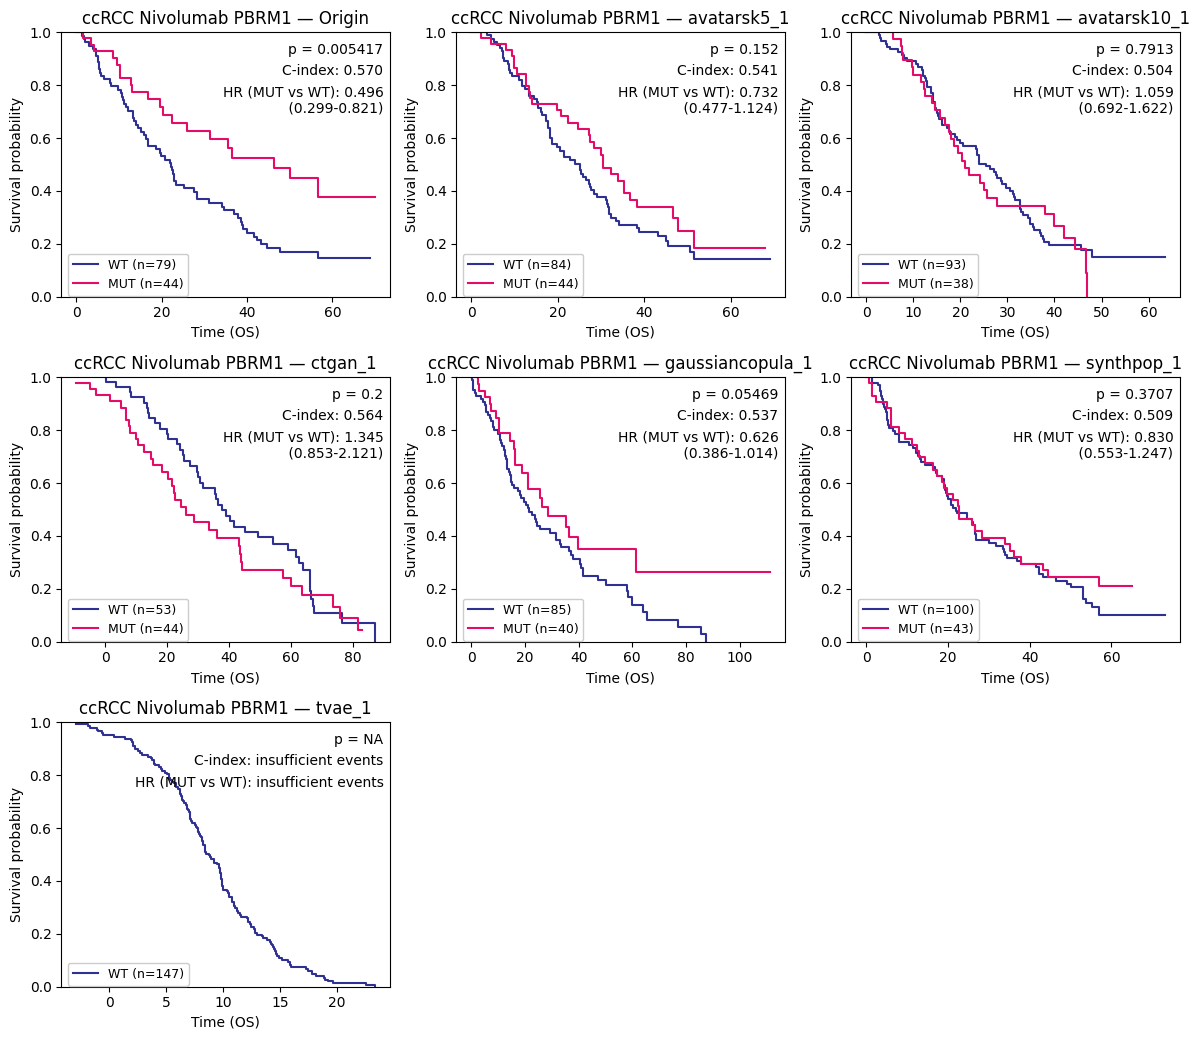

In [19]:
phenotype = {"PBRM1": ["MUT", "WT"]}
datasets_nivo = {}
arm = "NIVOLUMAB"
for k, df in dataset_dict.items():
    icb_df = df[df["Arm"]==arm] 
    datasets_nivo[k]=icb_df
fig, summary = plot_survival_grid(
    datasets_nivo,
    phenotype=phenotype,
    treatment=None,
    time_target="OS",
    event_target="OS_CNSR",
    ncols=3,
    figsize=None,
    show_censors=False,
    ci_show=False,
    title_prefix="ccRCC Nivolumab PBRM1",
)

print(summary)
fig.savefig(f"SurvivalAnalysis/Survival_PBRM1_{seed}.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_281928/2715742348.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CB/ICB' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  responders_df.loc[responder_indexes, "Responder"]= "CB/ICB"
/tmp/ipykernel_281928/2715742348.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CB/ICB' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  responders_df.loc[responder_indexes, "Responder"]= "CB/ICB"
/tmp/ipykernel_281928/2715742348.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CB/ICB' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  responders_df.loc[responder_indexes, "Responder"]= "CB/ICB"
/tmp/ipykernel_2819

           Datasets        pvalue C-index                     HR
0            Origin  7.008132e-06   0.611  0.448\n (0.313-0.642)
1       avatarsk5_1  1.363322e-07   0.617  0.417\n (0.299-0.583)
2      avatarsk10_1  2.756188e-08   0.616  0.393\n (0.280-0.552)
3           ctgan_1  6.261857e-01   0.521  1.093\n (0.763-1.567)
4  gaussiancopula_1  5.111674e-05   0.597  0.469\n (0.322-0.682)
5        synthpop_1  8.280893e-01   0.511  1.038\n (0.740-1.456)
6            tvae_1  2.408543e-01   0.508  0.589\n (0.240-1.442)


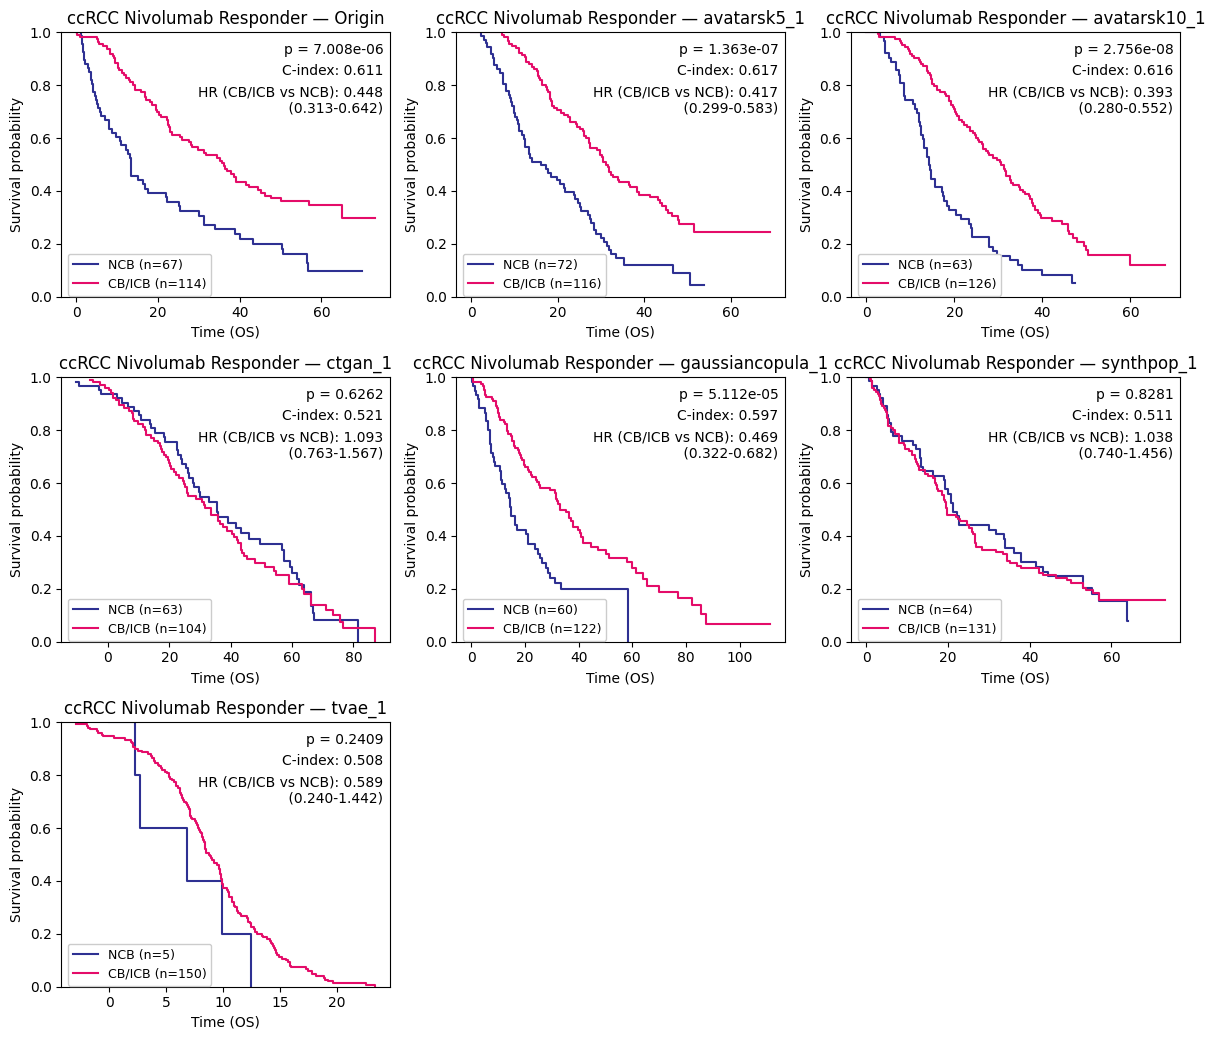

In [20]:
responders_datasets = {}
for k, df in datasets_nivo.items():
    responders_df = df.copy()
    responders_df["Responder"] = np.nan
    responder_indexes = responders_df[responders_df["Benefit"]!="NCB"].index
    responders_df.loc[responder_indexes, "Responder"]= "CB/ICB"
    progresso_indexes = responders_df[responders_df["Benefit"]=="NCB"].index
    responders_df.loc[progresso_indexes, "Responder"]="NCB"
    responders_datasets[k] = responders_df
phenotype_res = {"Responder":["CB/ICB","NCB"]}
fig_responders, summary_responders = plot_survival_grid(
    responders_datasets,
    phenotype=phenotype_res,
    treatment=None,
    time_target="OS",
    event_target="OS_CNSR",
    ncols=3,
    figsize=None,
    show_censors=False,
    ci_show=False,
    title_prefix="ccRCC Nivolumab Responder",
)

print(summary_responders)
fig_responders.savefig(f"SurvivalAnalysis/Survival_Responder_{seed}.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
responders_datasets = {}
for k, df in datasets_nivo.items():
    responders_df = df.copy()
    responders_df["Responder"] = np.nan
    responder_indexes = responders_df[responders_df["ORR"]!="PRCR"].index
    responders_df.loc[responder_indexes, "Responder"]= "CB/ICB"
    progresso_indexes = responders_df[responders_df["Benefit"]=="NCB"].index
    responders_df.loc[progresso_indexes, "Responder"]="NCB"
    responders_datasets[k] = responders_df
phenotype_res = {"Responder":["CB/ICB","NCB"]}
fig_responders, summary_responders = plot_survival_grid(
    responders_datasets,
    phenotype=phenotype_res,
    treatment=None,
    time_target="OS",
    event_target="OS_CNSR",
    ncols=3,
    figsize=None,
    show_censors=False,
    ci_show=False,
    title_prefix="ccRCC Nivolumab Responder",
)

print(summary_responders)
fig_responders.savefig(f"SurvivalAnalysis/Survival_Responder_{seed}.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# -*- coding: utf-8 -*-
"""
Compute similarity scores between an Original dataset and other (synthetic) datasets
based on p-value, C-index and Hazard Ratio (HR) metrics produced by survival analyses.

This module fixes a bug where missing numeric metrics (NaN) were treated as None and
led to scores of 1. Now any comparison involving a missing metric produces NaN score.

Args:
    This module exposes compute_similarity_scores(...) described below.

Returns:
    Provides compute_similarity_scores which returns a DataFrame with added score columns.

Raises:
    See compute_similarity_scores docstring.
"""
from typing import Optional
import re
import math

import numpy as np
import pandas as pd


def _parse_first_float(x: Optional[str]) -> Optional[float]:
    """
    Extract the first floating-point number from a string and return it as float.

    Args:
        x (str or numeric or None): Input value possibly containing a number.

    Returns:
        float or None: First number found, or None if none could be parsed.
    """
    if x is None:
        return None
    # If already numeric
    try:
        if isinstance(x, (int, float, np.floating, np.integer)):
            f = float(x)
            if math.isfinite(f):
                return f
            return None
    except Exception:
        pass

    s = str(x)
    m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
    if m:
        try:
            val = float(m.group(0))
            if math.isfinite(val):
                return val
        except Exception:
            return None
    return None


def compute_similarity_scores(summary_df: pd.DataFrame, original_name: str = "Original") -> pd.DataFrame:
    """
    Compute p-value, C-index and HR similarity scores relative to an Original dataset.

    Args:
        summary_df (pd.DataFrame): DataFrame with rows per dataset and columns:
            - 'Datasets' (dataset name)
            - 'pvalue'  (float or NaN)
            - 'C-index' (string or float)
            - 'HR'      (string or float; may include CI like "1.23 (0.5-3.0)")
        original_name (str): Name/key in the 'Datasets' column identifying the Original
            dataset. All other datasets will be compared against this one.

    Returns:
        pd.DataFrame: A copy of summary_df with three new columns appended:
            - 'pvalue_score'  (float or NaN)
            - 'C-index_score' (float or NaN)
            - 'HR_score'      (float or NaN)

    Raises:
        KeyError: If 'Datasets' column is missing or original_name not found.
    """
    if "Datasets" not in summary_df.columns:
        raise KeyError("'Datasets' column not found in summary_df")

    if original_name not in summary_df["Datasets"].values:
        raise KeyError(f"Original dataset '{original_name}' not found in summary_df['Datasets']")

    df = summary_df.copy().reset_index(drop=True)

    # parse numeric metrics for all rows; use np.nan to represent missing values
    parsed_p = []
    parsed_cindex = []
    parsed_hr = []

    for _, row in df.iterrows():
        # pvalue: accept numeric or parse from string
        p_raw = row.get("pvalue", None)
        p_val = None
        try:
            if p_raw is None:
                p_val = None
            elif isinstance(p_raw, (int, float, np.integer, np.floating)):
                p_val = float(p_raw)
                if not math.isfinite(p_val):
                    p_val = None
            else:
                p_val = _parse_first_float(p_raw)
        except Exception:
            p_val = _parse_first_float(p_raw)
        parsed_p.append(np.nan if p_val is None else float(p_val))

        # C-index: numeric or parse
        c_raw = row.get("C-index", None)
        c_val = None
        try:
            if c_raw is None:
                c_val = None
            elif isinstance(c_raw, (int, float, np.integer, np.floating)):
                c_val = float(c_raw)
                if not math.isfinite(c_val):
                    c_val = None
            else:
                c_val = _parse_first_float(c_raw)
        except Exception:
            c_val = _parse_first_float(c_raw)
        parsed_cindex.append(np.nan if c_val is None else float(c_val))

        # HR: extract first positive float
        hr_raw = row.get("HR", None)
        hr_val = None
        try:
            if hr_raw is None:
                hr_val = None
            elif isinstance(hr_raw, (int, float, np.integer, np.floating)):
                hr_val = float(hr_raw)
                if not math.isfinite(hr_val) or hr_val <= 0:
                    hr_val = None
            else:
                hr_val = _parse_first_float(hr_raw)
                if hr_val is None or hr_val <= 0 or not math.isfinite(hr_val):
                    hr_val = None
        except Exception:
            hr_val = _parse_first_float(hr_raw)
            if hr_val is None or hr_val <= 0 or not math.isfinite(hr_val):
                hr_val = None
        parsed_hr.append(np.nan if hr_val is None else float(hr_val))

    df["_pval_parsed"] = parsed_p
    df["_cindex_parsed"] = parsed_cindex
    df["_hr_parsed"] = parsed_hr

    # get original metrics (as numeric or NaN)
    orig_row = df[df["Datasets"] == original_name].iloc[0]
    p_orig = orig_row["_pval_parsed"]
    c_orig = orig_row["_cindex_parsed"]
    hr_orig = orig_row["_hr_parsed"]

    p_scores = []
    c_scores = []
    hr_scores = []

    for _, row in df.iterrows():
        p_syn = row["_pval_parsed"]
        c_syn = row["_cindex_parsed"]
        hr_syn = row["_hr_parsed"]

        # p-value score: 1 - |p_orig - p_syn| ; if either is NaN -> NaN
        if pd.isna(p_orig) or pd.isna(p_syn):
            p_score = np.nan
        else:
            diff = abs(p_orig - p_syn)
            p_score = 1.0 - diff
            p_score = max(0.0, min(1.0, p_score))
        p_scores.append(p_score)

        # C-index score: 1 - |C_orig - C_syn| ; if either is NaN -> NaN
        if pd.isna(c_orig) or pd.isna(c_syn):
            c_score = np.nan
        else:
            diff_c = abs(c_orig - c_syn)
            c_score = 1.0 - diff_c
            c_score = max(0.0, min(1.0, c_score))
        c_scores.append(c_score)

        # HR score: exp(-|log(HR_orig) - log(HR_syn)|) ; if either missing -> NaN
        if pd.isna(hr_orig) or pd.isna(hr_syn):
            hr_score = np.nan
        else:
            try:
                logdiff = abs(math.log(hr_orig) - math.log(hr_syn))
                hr_score = math.exp(-logdiff)
            except Exception:
                hr_score = np.nan
        hr_scores.append(hr_score)

    df["pvalue_score"] = p_scores
    df["C-index_score"] = c_scores
    df["HR_score"] = hr_scores

    # drop helper parsed columns before returning
    df = df.drop(columns=["_pval_parsed", "_cindex_parsed", "_hr_parsed"])

    return df


# if __name__ == "__main__":
#     # Demonstration including a dataset with missing phenotype metrics
#     sample = pd.DataFrame(
#         [
#             {"Datasets": "Original", "pvalue": 0.03, "C-index": "0.72", "HR": "1.50 (1.1-2.0)"},
#             {"Datasets": "SynthA", "pvalue": 0.05, "C-index": "0.70", "HR": "1.40 (0.9-2.2)"},
#             # TVAE: not enough phenotype -> metrics are NaN (or strings like "NA")
#             {"Datasets": "TVAE", "pvalue": np.nan, "C-index": "insufficient variation", "HR": "NA"},
#         ]
#     )

#     scored = compute_similarity_scores(sample, original_name="Original")
#     # Print relevant columns
#     print(scored[["Datasets", "pvalue", "pvalue_score", "C-index", "C-index_score", "HR", "HR_score"]])

In [22]:
scored = compute_similarity_scores(summary, original_name="Origin")
pvalues = scored["pvalue_score"].values
cindex_scores = scored["C-index_score"].values
hr_scores = scored["HR_score"].values
avarages_scores = 1/3*(pvalues+cindex_scores+hr_scores)
scored["Average"] = avarages_scores
scored.to_csv(f"SurvivalAnalysis/Survival_PBRM1_{seed}.csv", index = False)

In [23]:
scored_responder = compute_similarity_scores(summary_responders, original_name="Origin")
pvalues = scored_responder["pvalue_score"].values
cindex_scores = scored_responder["C-index_score"].values
hr_scores = scored_responder["HR_score"].values
avarages_scores = 1/3*(pvalues+cindex_scores+hr_scores)
scored_responder["Average"] = avarages_scores
scored_responder.to_csv(f"SurvivalAnalysis/Survival_Responder_{seed}.csv", index = False)